# ANÁLISIS DE SERIES DE TIEMPO - MODELO PROPHET
## Producto 1

## 1. IMPORTACIONES Y CONFIGURACIÓN

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Prophet
try:
    from prophet import Prophet
    prophet_available = True
    print("Prophet importado correctamente")
except ImportError:
    try:
        from fbprophet import Prophet
        prophet_available = True
        print("fbprophet importado correctamente")
    except ImportError:
        prophet_available = False
        print("Error: Prophet no está disponible. Instala con: pip install prophet")

# Métricas y optimización
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Prophet importado correctamente
Fecha de análisis: 2025-12-06 23:24


## 2. CARGA DE DATOS

In [26]:
# Cargar datos preparados
with open('datasets_preparados.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Extraer datasets
data = datasets['data']
train_to1 = datasets['train_to1']
test_to1 = datasets['test_to1']
train_len = datasets['train_len']

print("Datos cargados exitosamente")
print(f"Total observaciones: {len(data)}")
print(f"Conjunto entrenamiento: {len(train_to1)}")
print(f"Conjunto prueba: {len(test_to1)}")
print(f"\nPrimeras observaciones Producto 1:")
print(train_to1['producto1'].head())

Datos cargados exitosamente
Total observaciones: 127
Conjunto entrenamiento: 121
Conjunto prueba: 6

Primeras observaciones Producto 1:
0    500.000000
1    497.400893
2    478.605317
3    486.454125
4    479.695678
Name: producto1, dtype: float64


## 3. PREPARACIÓN DE DATOS PARA PROPHET

In [27]:
# Prophet requiere columnas específicas: 'ds' (fecha) y 'y' (valor)
# Crear fechas sintéticas (Prophet necesita fechas reales)
start_date = datetime(2020, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(len(data))]

# Preparar datos de entrenamiento para Producto 1
df_prophet_train = pd.DataFrame({
    'ds': dates[:train_len],
    'y': train_to1['producto1'].values
})

# Preparar datos de prueba para Producto 1
df_prophet_test = pd.DataFrame({
    'ds': dates[train_len:],
    'y': test_to1['producto1'].values
})

# Dataset completo
df_prophet_completo = pd.DataFrame({
    'ds': dates,
    'y': data['producto1'].values
})

print("Datos preparados para Prophet")
print(f"Train: {df_prophet_train.shape}")
print(f"Test: {df_prophet_test.shape}")
print(f"Completo: {df_prophet_completo.shape}")
print(f"\nRango de fechas: {dates[0].strftime('%Y-%m-%d')} a {dates[-1].strftime('%Y-%m-%d')}")
print(f"\nPrimeras filas dataset entrenamiento:")
print(df_prophet_train.head())

Datos preparados para Prophet
Train: (121, 2)
Test: (6, 2)
Completo: (127, 2)

Rango de fechas: 2020-01-01 a 2020-05-06

Primeras filas dataset entrenamiento:
          ds           y
0 2020-01-01  500.000000
1 2020-01-02  497.400893
2 2020-01-03  478.605317
3 2020-01-04  486.454125
4 2020-01-05  479.695678


## 4. ANÁLISIS EXPLORATORIO DE LA SERIE

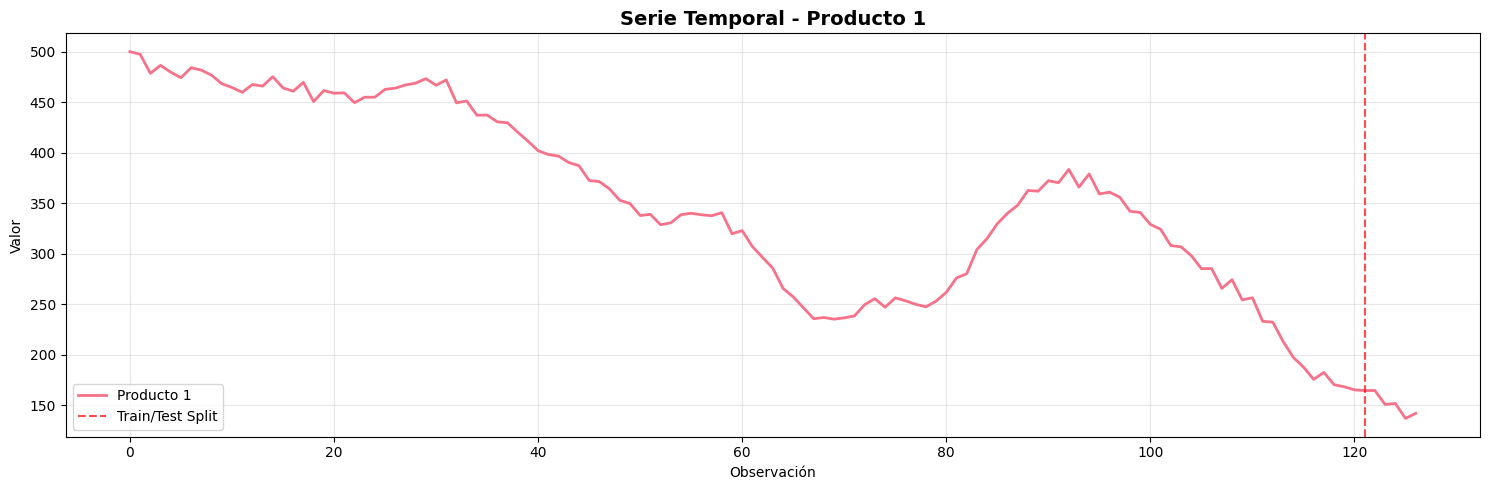

Estadísticas de la serie:
Media: 343.57
Desviación estándar: 100.23
Mínimo: 137.05
Máximo: 500.00

Cambio total: -358.01
Tasa de cambio: -71.60%


In [28]:
# Visualizar la serie temporal completa
plt.figure(figsize=(15, 5))
plt.plot(data.index, data['producto1'], label='Producto 1', linewidth=2)
plt.axvline(x=train_len, color='red', linestyle='--', label='Train/Test Split', alpha=0.7)
plt.title('Serie Temporal - Producto 1', fontsize=14, fontweight='bold')
plt.xlabel('Observación')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("Estadísticas de la serie:")
print(f"Media: {data['producto1'].mean():.2f}")
print(f"Desviación estándar: {data['producto1'].std():.2f}")
print(f"Mínimo: {data['producto1'].min():.2f}")
print(f"Máximo: {data['producto1'].max():.2f}")
print(f"\nCambio total: {data['producto1'].iloc[-1] - data['producto1'].iloc[0]:.2f}")
print(f"Tasa de cambio: {((data['producto1'].iloc[-1] / data['producto1'].iloc[0]) - 1) * 100:.2f}%")

## 5. OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA

In [30]:
def objective_prophet(trial):
    """
    Función objetivo para optimización de hiperparámetros de Prophet
    Usa validación con ventana móvil para evaluar el modelo
    """
    # Hiperparámetros a optimizar
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10, log=True),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.01, 10, log=True),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.8, 0.95)
    }
    
    # Validación con ventana móvil
    window_size = int(len(df_prophet_train) * 0.7)
    predicciones = []
    valores_reales = []
    
    for i in range(len(df_prophet_train) - window_size):
        # Ventana de entrenamiento
        train_window = df_prophet_train.iloc[i:i+window_size]
        
        # Siguiente valor a predecir
        test_point = df_prophet_train.iloc[i+window_size]
        
        try:
            # Crear y entrenar modelo
            model = Prophet(
                changepoint_prior_scale=params['changepoint_prior_scale'],
                seasonality_prior_scale=params['seasonality_prior_scale'],
                holidays_prior_scale=params['holidays_prior_scale'],
                seasonality_mode=params['seasonality_mode'],
                changepoint_range=params['changepoint_range'],
                yearly_seasonality='auto',
                weekly_seasonality='auto',
                daily_seasonality=False
            )
            
            model.fit(train_window)
            
            # Predecir 1 paso adelante
            future = model.make_future_dataframe(periods=1)
            forecast = model.predict(future)
            pred = forecast['yhat'].iloc[-1]
            
            predicciones.append(pred)
            valores_reales.append(test_point['y'])
            
        except Exception as e:
            return np.inf
    
    # Calcular RMSE
    rmse = np.sqrt(mean_squared_error(valores_reales, predicciones))
    return rmse

# Ejecutar optimización
print("=" * 70)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS PROPHET - PRODUCTO 1")
print("=" * 70)
print("Iniciando optimización con Optuna...")
print("Esto puede tomar varios minutos...")
print("-" * 70)

study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective_prophet, n_trials=5, timeout=600, show_progress_bar=True)

print("\n" + "=" * 70)
print("RESULTADOS DE OPTIMIZACIÓN")
print("=" * 70)
print(f"Mejor RMSE: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")
print(f"\nTrials completados: {len(study.trials)}")
print("=" * 70)

[I 2025-12-06 23:30:29,918] A new study created in memory with name: no-name-3132ee89-b626-4d8b-b419-ad1dc19bc898


OPTIMIZACIÓN DE HIPERPARÁMETROS PROPHET - PRODUCTO 1
Iniciando optimización con Optuna...
Esto puede tomar varios minutos...
----------------------------------------------------------------------


  0%|          | 0/5 [00:00<?, ?it/s]

23:30:30 - cmdstanpy - INFO - Chain [1] start processing
23:30:30 - cmdstanpy - INFO - Chain [1] done processing
23:30:30 - cmdstanpy - INFO - Chain [1] done processing
23:30:30 - cmdstanpy - INFO - Chain [1] start processing
23:30:30 - cmdstanpy - INFO - Chain [1] start processing
23:30:30 - cmdstanpy - INFO - Chain [1] done processing
23:30:30 - cmdstanpy - INFO - Chain [1] done processing
23:30:31 - cmdstanpy - INFO - Chain [1] start processing
23:30:31 - cmdstanpy - INFO - Chain [1] start processing
23:30:31 - cmdstanpy - INFO - Chain [1] done processing
23:30:31 - cmdstanpy - INFO - Chain [1] done processing
23:30:31 - cmdstanpy - INFO - Chain [1] start processing
23:30:31 - cmdstanpy - INFO - Chain [1] start processing
23:30:32 - cmdstanpy - INFO - Chain [1] done processing
23:30:32 - cmdstanpy - INFO - Chain [1] done processing
23:30:32 - cmdstanpy - INFO - Chain [1] start processing
23:30:32 - cmdstanpy - INFO - Chain [1] start processing
23:30:32 - cmdstanpy - INFO - Chain [1]

[I 2025-12-06 23:30:47,403] Trial 0 finished with value: 86.7857932559793 and parameters: {'changepoint_prior_scale': 0.0213931858061771, 'seasonality_prior_scale': 0.4299892479037362, 'holidays_prior_scale': 0.2785534143661607, 'seasonality_mode': 'additive', 'changepoint_range': 0.8235994241056598}. Best is trial 0 with value: 86.7857932559793.


...

[I 2025-12-06 23:31:29,168] Trial 2 finished with value: 86.18649414031454 and parameters: {'changepoint_prior_scale': 0.012257024961187378, 'seasonality_prior_scale': 0.04897903468716945, 'holidays_prior_scale': 0.061070244644155926, 'seasonality_mode': 'additive', 'changepoint_range': 0.8548426734301477}. Best is trial 1 with value: 26.803778284535653.


23:31:29 - cmdstanpy - INFO - Chain [1] done processing
23:31:29 - cmdstanpy - INFO - Chain [1] start processing
23:31:29 - cmdstanpy - INFO - Chain [1] start processing
23:31:29 - cmdstanpy - INFO - Chain [1] done processing
23:31:29 - cmdstanpy - INFO - Chain [1] done processing
23:31:29 - cmdstanpy - INFO - Chain [1] start processing
23:31:29 - cmdstanpy - INFO - Chain [1] start processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] start processing
23:31:30 - cmdstanpy - INFO - Chain [1] start processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] start processing
23:31:30 - cmdstanpy - INFO - Chain [1] start processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] done processing
23:31:30 - cmdstanpy - INFO - Chain [1] 

[I 2025-12-06 23:31:43,159] Trial 3 finished with value: 84.74010783632096 and parameters: {'changepoint_prior_scale': 0.0015369797534576233, 'seasonality_prior_scale': 5.756400035069557, 'holidays_prior_scale': 0.6419958143779064, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9196269006576873}. Best is trial 1 with value: 26.803778284535653.


23:31:43 - cmdstanpy - INFO - Chain [1] done processing
23:31:43 - cmdstanpy - INFO - Chain [1] start processing
23:31:43 - cmdstanpy - INFO - Chain [1] start processing
23:31:44 - cmdstanpy - INFO - Chain [1] done processing
23:31:44 - cmdstanpy - INFO - Chain [1] done processing
23:31:44 - cmdstanpy - INFO - Chain [1] start processing
23:31:44 - cmdstanpy - INFO - Chain [1] start processing
23:31:44 - cmdstanpy - INFO - Chain [1] done processing
23:31:44 - cmdstanpy - INFO - Chain [1] done processing
23:31:45 - cmdstanpy - INFO - Chain [1] start processing
23:31:45 - cmdstanpy - INFO - Chain [1] start processing
23:31:45 - cmdstanpy - INFO - Chain [1] done processing
23:31:45 - cmdstanpy - INFO - Chain [1] done processing
23:31:45 - cmdstanpy - INFO - Chain [1] start processing
23:31:45 - cmdstanpy - INFO - Chain [1] start processing
23:31:46 - cmdstanpy - INFO - Chain [1] done processing
23:31:46 - cmdstanpy - INFO - Chain [1] done processing
23:31:46 - cmdstanpy - INFO - Chain [1] 

[I 2025-12-06 23:32:09,401] Trial 4 finished with value: 15.176598626257231 and parameters: {'changepoint_prior_scale': 0.16962037869815325, 'seasonality_prior_scale': 0.2340111874775026, 'holidays_prior_scale': 0.11731653405009046, 'seasonality_mode': 'additive', 'changepoint_range': 0.9140378196888596}. Best is trial 4 with value: 15.176598626257231.

RESULTADOS DE OPTIMIZACIÓN
Mejor RMSE: 15.1766

Mejores hiperparámetros:
  changepoint_prior_scale: 0.169620
  seasonality_prior_scale: 0.234011
  holidays_prior_scale: 0.117317
  seasonality_mode: additive
  changepoint_range: 0.914038

Trials completados: 5


## 6. MODELO ÓPTIMO CON CONJUNTO DE ENTRENAMIENTO

In [ ]:
# Entrenar modelo con mejores hiperparámetros
best_params = study.best_params

modelo_prophet_optimo = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    holidays_prior_scale=best_params['holidays_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_range=best_params['changepoint_range'],
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality=False
)

print("Entrenando modelo óptimo con datos de entrenamiento...")
modelo_prophet_optimo.fit(df_prophet_train)
print("Modelo óptimo entrenado exitosamente")

23:15:24 - cmdstanpy - INFO - Chain [1] start processing
23:15:24 - cmdstanpy - INFO - Chain [1] done processing
23:15:24 - cmdstanpy - INFO - Chain [1] done processing


Entrenando modelo óptimo con datos de entrenamiento...
Modelo óptimo entrenado exitosamente


## 7. EVALUACIÓN EN CONJUNTO DE PRUEBA

In [ ]:
# Generar pronósticos para conjunto de prueba
future = modelo_prophet_optimo.make_future_dataframe(periods=len(df_prophet_test))
forecast = modelo_prophet_optimo.predict(future)

# Extraer predicciones
pred_test = forecast['yhat'][-len(df_prophet_test):].values
true_test = df_prophet_test['y'].values

# Calcular métricas
rmse_test = np.sqrt(mean_squared_error(true_test, pred_test))
mae_test = mean_absolute_error(true_test, pred_test)

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA")
print("=" * 60)
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"\nPrimeros 5 pronósticos vs valores reales:")
comparacion = pd.DataFrame({
    'Fecha': df_prophet_test['ds'].head().values,
    'Real': true_test[:5],
    'Pronóstico': pred_test[:5],
    'Error': true_test[:5] - pred_test[:5]
})
print(comparacion.to_string(index=False))
print("=" * 60)

EVALUACIÓN EN CONJUNTO DE PRUEBA
RMSE: 24.4666
MAE: 24.0401

Primeros 5 pronósticos vs valores reales:
     Fecha       Real  Pronóstico     Error
2020-05-01 164.625472  146.781713 17.843758
2020-05-02 164.610771  139.968552 24.642219
2020-05-03 150.881839  128.711305 22.170534
2020-05-04 151.788470  124.785071 27.003399
2020-05-05 137.047639  116.367936 20.679703


## 8. VISUALIZACIÓN DE PRONÓSTICOS

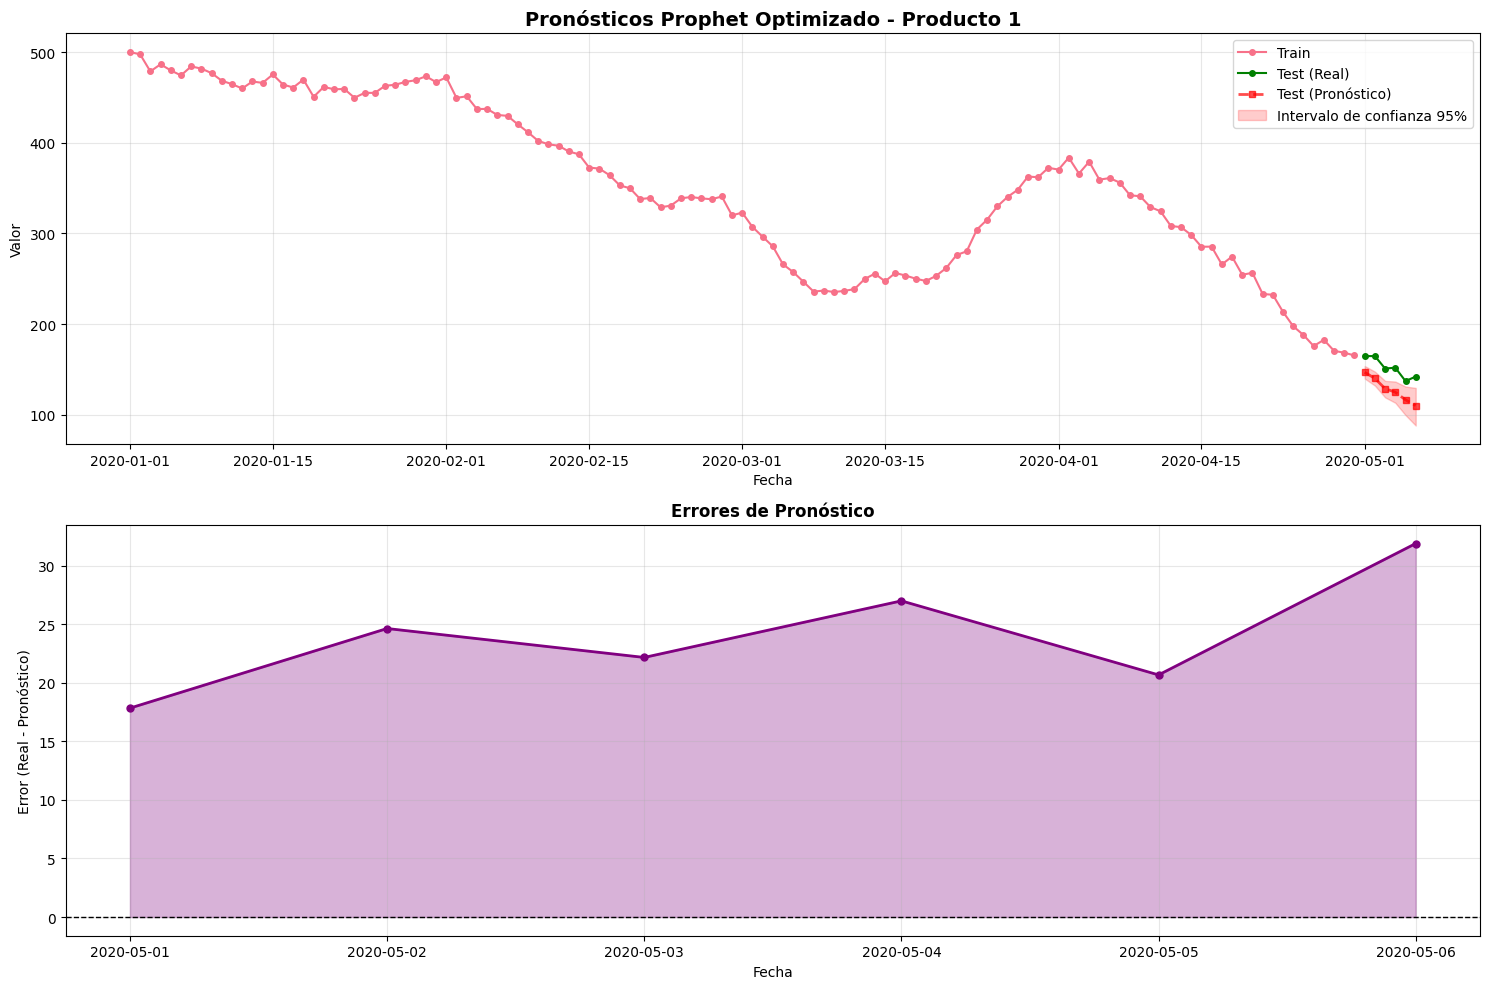

In [ ]:
# Visualización detallada de pronósticos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Serie completa con pronósticos
ax1.plot(df_prophet_train['ds'], df_prophet_train['y'], 'o-', label='Train', markersize=4, linewidth=1.5)
ax1.plot(df_prophet_test['ds'], df_prophet_test['y'], 'o-', label='Test (Real)', markersize=4, linewidth=1.5, color='green')
ax1.plot(df_prophet_test['ds'], pred_test, 's--', label='Test (Pronóstico)', markersize=5, linewidth=2, color='red', alpha=0.7)
ax1.fill_between(df_prophet_test['ds'], 
                  forecast['yhat_lower'][-len(df_prophet_test):].values,
                  forecast['yhat_upper'][-len(df_prophet_test):].values,
                  alpha=0.2, color='red', label='Intervalo de confianza 95%')
ax1.set_title('Pronósticos Prophet Optimizado - Producto 1', fontsize=14, fontweight='bold')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Valor')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Errores de pronóstico
errores = true_test - pred_test
ax2.plot(df_prophet_test['ds'], errores, 'o-', color='purple', markersize=5, linewidth=2)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.fill_between(df_prophet_test['ds'], errores, 0, alpha=0.3, color='purple')
ax2.set_title('Errores de Pronóstico', fontsize=12, fontweight='bold')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Error (Real - Pronóstico)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. COMPONENTES DEL MODELO

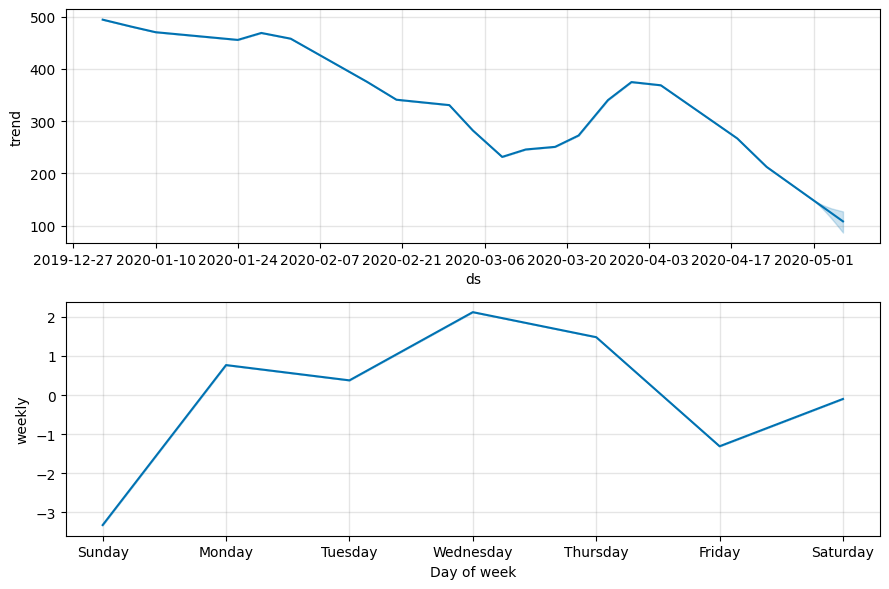


Puntos de cambio detectados por el modelo:
Total de changepoints: 25
Primeros 5: [Timestamp('2020-01-06 00:00:00'), Timestamp('2020-01-10 00:00:00'), Timestamp('2020-01-15 00:00:00'), Timestamp('2020-01-19 00:00:00'), Timestamp('2020-01-24 00:00:00')]
Últimos 5: [Timestamp('2020-04-05 00:00:00'), Timestamp('2020-04-09 00:00:00'), Timestamp('2020-04-14 00:00:00'), Timestamp('2020-04-18 00:00:00'), Timestamp('2020-04-23 00:00:00')]


In [ ]:
# Visualizar componentes del modelo (tendencia, estacionalidad, changepoints)
fig_components = modelo_prophet_optimo.plot_components(forecast)
plt.tight_layout()
plt.show()

# Mostrar changepoints detectados
print("\nPuntos de cambio detectados por el modelo:")
changepoints = modelo_prophet_optimo.changepoints
print(f"Total de changepoints: {len(changepoints)}")
print(f"Primeros 5: {changepoints[:5].tolist()}")
print(f"Últimos 5: {changepoints[-5:].tolist()}")

## 10. MODELO CON DATASET COMPLETO Y PRONÓSTICOS FUTUROS

In [ ]:
# Entrenar modelo final con dataset completo
modelo_prophet_completo = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    holidays_prior_scale=best_params['holidays_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_range=best_params['changepoint_range'],
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality=False
)

print("Entrenando modelo con dataset completo...")
modelo_prophet_completo.fit(df_prophet_completo)

# Generar pronósticos futuros (12 períodos)
future_completo = modelo_prophet_completo.make_future_dataframe(periods=12)
forecast_completo = modelo_prophet_completo.predict(future_completo)

print("Modelo entrenado con dataset completo")
print(f"\nÚltimos 5 pronósticos futuros:")
print(forecast_completo[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

23:15:26 - cmdstanpy - INFO - Chain [1] start processing


Entrenando modelo con dataset completo...


23:15:26 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado con dataset completo

Últimos 5 pronósticos futuros:
            ds        yhat  yhat_lower  yhat_upper
134 2020-05-14  107.134206   70.800339  141.416135
135 2020-05-15  102.355565   55.463909  146.029071
136 2020-05-16  100.882230   46.679489  152.006538
137 2020-05-17   92.921299   32.668464  155.596167
138 2020-05-18   91.823560   17.892139  161.625279


## 11. VISUALIZACIÓN DE PRONÓSTICOS FUTUROS

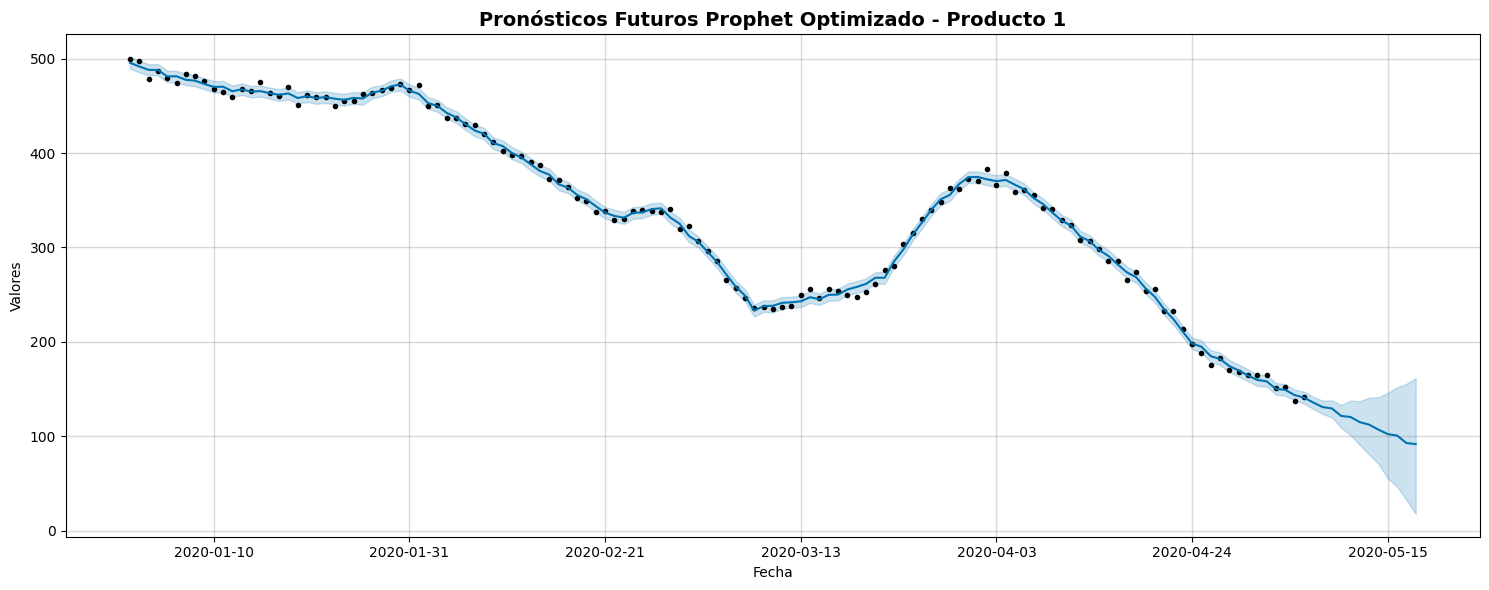

In [ ]:
# Visualizar pronósticos futuros
fig = modelo_prophet_completo.plot(forecast_completo, figsize=(15, 6))
plt.title('Pronósticos Futuros Prophet Optimizado - Producto 1', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Valores')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. RESUMEN DE MÉTRICAS Y COMPARACIÓN

---
# PRODUCTO 2

## 14. ANÁLISIS EXPLORATORIO DE LA SERIE - PRODUCTO 2

In [ ]:
print("="*80)
print("ANÁLISIS EXPLORATORIO - PRODUCTO 2")
print("="*80)

print(f"\n📊 Tamaño del dataset completo: {len(data)} observaciones")
print(f"📈 Tamaño del conjunto de entrenamiento: {len(train_to2)} ({len(train_to2)/len(data)*100:.1f}%)")
print(f"📉 Tamaño del conjunto de test: {len(test_to2)} ({len(test_to2)/len(data)*100:.1f}%)")

print(f"\n🔹 Estadísticas del conjunto de entrenamiento:")
print(train_to2['y'].describe())

print(f"\n🔹 Tendencia observada:")
print(f"   Valor inicial: {train_to2['y'].iloc[0]:.2f}")
print(f"   Valor final: {train_to2['y'].iloc[-1]:.2f}")
print(f"   Cambio: {train_to2['y'].iloc[-1] - train_to2['y'].iloc[0]:.2f} ({((train_to2['y'].iloc[-1]/train_to2['y'].iloc[0])-1)*100:.1f}%)")

plt.figure(figsize=(15, 5))
plt.plot(train_to2['ds'], train_to2['y'], label='Train - Producto 2', color='blue', linewidth=2)
plt.plot(test_to2['ds'], test_to2['y'], label='Test - Producto 2', color='orange', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.title('Serie Temporal - Producto 2 (Train vs Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. OPTIMIZACIÓN CON OPTUNA - PRODUCTO 2

In [ ]:
def objective_prophet_p2(trial):
    """
    Función objetivo para optimizar hiperparámetros de Prophet en Producto 2
    """
    # Hiperparámetros a optimizar
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10, log=True)
    seasonality_mode = trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative'])
    changepoint_range = trial.suggest_float('changepoint_range', 0.8, 0.95)
    
    # Validación cruzada con ventana deslizante
    train_size = int(len(train_to2) * 0.7)
    rmse_list = []
    
    for i in range(3):
        end_idx = train_size + i * 5
        if end_idx > len(train_to2):
            break
        
        train_fold = train_to2.iloc[:end_idx]
        val_fold = train_to2.iloc[end_idx:min(end_idx+10, len(train_to2))]
        
        if len(val_fold) < 5:
            break
        
        # Entrenar modelo
        model = Prophet(
            changepoint_prior_scale=changepoint_prior_scale,
            seasonality_prior_scale=seasonality_prior_scale,
            holidays_prior_scale=holidays_prior_scale,
            seasonality_mode=seasonality_mode,
            changepoint_range=changepoint_range,
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        
        with suppress_stdout_stderr():
            model.fit(train_fold)
        
        # Predecir
        forecast = model.predict(val_fold)
        
        # Calcular RMSE
        rmse = np.sqrt(mean_squared_error(val_fold['y'].values, forecast['yhat'].values))
        rmse_list.append(rmse)
    
    # Retornar RMSE promedio
    return np.mean(rmse_list) if rmse_list else float('inf')

print("="*80)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS - PRODUCTO 2")
print("="*80)

# Crear estudio de Optuna
study_p2 = optuna.create_study(direction='minimize', study_name='prophet_optimization_p2')

# Ejecutar optimización
study_p2.optimize(objective_prophet_p2, n_trials=30, timeout=600, show_progress_bar=True)

# Mostrar mejores hiperparámetros
print("\n" + "="*80)
print("RESULTADOS DE LA OPTIMIZACIÓN - PRODUCTO 2")
print("="*80)
print(f"\n✅ Mejor RMSE (validación cruzada): {study_p2.best_value:.4f}")
print(f"\n🎯 Mejores hiperparámetros:")
for param, value in study_p2.best_params.items():
    print(f"   {param}: {value}")

# Guardar mejores parámetros
best_params_p2 = study_p2.best_params
best_rmse_cv_p2 = study_p2.best_value

## 16. ENTRENAMIENTO DEL MODELO ÓPTIMO - PRODUCTO 2

In [ ]:
print("="*80)
print("ENTRENAMIENTO DEL MODELO ÓPTIMO - PRODUCTO 2")
print("="*80)

# Crear y entrenar el modelo con los mejores hiperparámetros
model_opt_p2 = Prophet(
    changepoint_prior_scale=best_params_p2['changepoint_prior_scale'],
    seasonality_prior_scale=best_params_p2['seasonality_prior_scale'],
    holidays_prior_scale=best_params_p2['holidays_prior_scale'],
    seasonality_mode=best_params_p2['seasonality_mode'],
    changepoint_range=best_params_p2['changepoint_range'],
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

with suppress_stdout_stderr():
    model_opt_p2.fit(train_to2)

print("\n✅ Modelo óptimo entrenado exitosamente para Producto 2")

## 17. EVALUACIÓN EN CONJUNTO DE TEST - PRODUCTO 2

In [ ]:
print("="*80)
print("EVALUACIÓN EN CONJUNTO DE TEST - PRODUCTO 2")
print("="*80)

# Realizar predicciones en el conjunto de test
forecast_test_p2 = model_opt_p2.predict(test_to2)

# Calcular métricas
y_true_p2 = test_to2['y'].values
y_pred_p2 = forecast_test_p2['yhat'].values

rmse_test_p2 = np.sqrt(mean_squared_error(y_true_p2, y_pred_p2))
mae_test_p2 = mean_absolute_error(y_true_p2, y_pred_p2)
mape_test_p2 = np.mean(np.abs((y_true_p2 - y_pred_p2) / y_true_p2)) * 100

print(f"\n📊 MÉTRICAS EN CONJUNTO DE TEST - PRODUCTO 2:")
print(f"   RMSE: {rmse_test_p2:.4f}")
print(f"   MAE:  {mae_test_p2:.4f}")
print(f"   MAPE: {mape_test_p2:.2f}%")

# Calcular errores
errores_test_p2 = y_true_p2 - y_pred_p2

# Guardar métricas
metricas_p2 = {
    'rmse_test': rmse_test_p2,
    'mae_test': mae_test_p2,
    'mape_test': mape_test_p2
}

## 18. VISUALIZACIÓN DE PREDICCIONES Y ERRORES - PRODUCTO 2

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Predicciones vs Valores Reales
axes[0].plot(train_to2['ds'], train_to2['y'], label='Train', color='blue', linewidth=2)
axes[0].plot(test_to2['ds'], test_to2['y'], label='Test (Real)', color='green', linewidth=2)
axes[0].plot(test_to2['ds'], y_pred_p2, label='Predicción Prophet', color='red', linewidth=2, linestyle='--')
axes[0].fill_between(forecast_test_p2['ds'], 
                      forecast_test_p2['yhat_lower'], 
                      forecast_test_p2['yhat_upper'], 
                      alpha=0.2, color='red', label='Intervalo de confianza')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Ventas')
axes[0].set_title('Predicciones Prophet vs Valores Reales - Producto 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Errores de Predicción
axes[1].plot(test_to2['ds'], errores_test_p2, color='red', linewidth=2, marker='o')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(test_to2['ds'], errores_test_p2, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Error (Real - Predicción)')
axes[1].set_title('Errores de Predicción - Producto 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 19. COMPONENTES DEL MODELO - PRODUCTO 2

In [ ]:
fig = model_opt_p2.plot_components(forecast_test_p2, figsize=(15, 8))
plt.suptitle('Componentes del Modelo Prophet - Producto 2', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Mostrar changepoints detectados
print(f"\n🔍 Número de changepoints detectados: {len(model_opt_p2.changepoints)}")
print(f"📅 Primeros 5 changepoints: {model_opt_p2.changepoints[:5].tolist()}")
print(f"📅 Últimos 5 changepoints: {model_opt_p2.changepoints[-5:].tolist()}")

## 20. MODELO CON DATASET COMPLETO Y FORECASTS FUTUROS - PRODUCTO 2

In [ ]:
print("="*80)
print("MODELO CON DATASET COMPLETO - PRODUCTO 2")
print("="*80)

# Preparar dataset completo
df_completo_p2 = pd.DataFrame({
    'ds': data.index,
    'y': data['producto2'].values
})

# Entrenar modelo con dataset completo
model_completo_p2 = Prophet(
    changepoint_prior_scale=best_params_p2['changepoint_prior_scale'],
    seasonality_prior_scale=best_params_p2['seasonality_prior_scale'],
    holidays_prior_scale=best_params_p2['holidays_prior_scale'],
    seasonality_mode=best_params_p2['seasonality_mode'],
    changepoint_range=best_params_p2['changepoint_range'],
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

with suppress_stdout_stderr():
    model_completo_p2.fit(df_completo_p2)

# Generar forecasts para los próximos 12 meses
future_p2 = model_completo_p2.make_future_dataframe(periods=12, freq='M')
forecast_futuro_p2 = model_completo_p2.predict(future_p2)

print("\n✅ Modelo completo entrenado exitosamente para Producto 2")
print(f"📅 Forecasts generados para los próximos 12 meses")

## 21. VISUALIZACIÓN DE FORECASTS FUTUROS - PRODUCTO 2

In [ ]:
fig = model_completo_p2.plot(forecast_futuro_p2, figsize=(15, 6))
plt.title('Forecasts Futuros con Prophet - Producto 2', fontsize=16)
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabla de forecasts futuros
print("\n" + "="*80)
print("FORECASTS PARA LOS PRÓXIMOS 12 MESES - PRODUCTO 2")
print("="*80)
forecasts_futuros_p2 = forecast_futuro_p2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
print(forecasts_futuros_p2.to_string(index=False))

## 22. COMPARACIÓN CON ARIMA - PRODUCTO 2

In [ ]:
print("="*80)
print("COMPARACIÓN: PROPHET VS ARIMA - PRODUCTO 2")
print("="*80)

# Cargar resultados de ARIMA si existen
try:
    with open('resultados_ARIMA.pkl', 'rb') as f:
        resultados_arima = pickle.load(f)
    
    rmse_arima_p2 = resultados_arima['producto2']['rmse_rolling_opt']
    
    print(f"\n📊 RMSE en conjunto de Test:")
    print(f"   Prophet: {rmse_test_p2:.4f}")
    print(f"   ARIMA:   {rmse_arima_p2:.4f}")
    
    if rmse_test_p2 < rmse_arima_p2:
        mejora = ((rmse_arima_p2 - rmse_test_p2) / rmse_arima_p2) * 100
        print(f"\n✅ Prophet es mejor que ARIMA")
        print(f"   Mejora: {mejora:.2f}%")
    else:
        diferencia = ((rmse_test_p2 - rmse_arima_p2) / rmse_arima_p2) * 100
        print(f"\n⚠️ ARIMA es mejor que Prophet")
        print(f"   Diferencia: {diferencia:.2f}%")
        
except FileNotFoundError:
    print("\n⚠️ No se encontró el archivo 'resultados_ARIMA.pkl'")
    print("   No se puede realizar la comparación con ARIMA")

In [ ]:
# Resumen completo de resultados
print("=" * 70)
print("RESUMEN FINAL - PROPHET OPTIMIZADO PRODUCTO 1")
print("=" * 70)

print("\nHIPERPARÁMETROS ÓPTIMOS:")
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")

print(f"\nMÉTRICAS DE EVALUACIÓN:")
print(f"  RMSE en conjunto de prueba: {rmse_test:.4f}")
print(f"  MAE en conjunto de prueba: {mae_test:.4f}")
print(f"  RMSE optimización (validación cruzada): {study.best_value:.4f}")

print(f"\nDATOS:")
print(f"  Observaciones entrenamiento: {len(df_prophet_train)}")
print(f"  Observaciones prueba: {len(df_prophet_test)}")
print(f"  Total observaciones: {len(df_prophet_completo)}")

print(f"\nPRONÓSTICOS:")
print(f"  Períodos futuros: 12")
print(f"  Último valor observado: {df_prophet_completo['y'].iloc[-1]:.2f}")
print(f"  Pronóstico próximo período: {forecast_completo['yhat'].iloc[-12]:.2f}")

# Comparar con otros modelos si existen
try:
    with open('resultados_ARIMA.pkl', 'rb') as f:
        resultados_arima = pickle.load(f)
    
    rmse_arima = resultados_arima['producto1']['rmse_rolling_opt']
    
    print(f"\nCOMPARACIÓN CON OTROS MODELOS:")
    print(f"  Prophet (optimizado): {rmse_test:.4f}")
    print(f"  ARIMA (optimizado): {rmse_arima:.4f}")
    
    if rmse_test < rmse_arima:
        print(f"  Prophet es MEJOR por {rmse_arima - rmse_test:.4f} puntos de RMSE")
    else:
        print(f"  ARIMA es MEJOR por {rmse_test - rmse_arima:.4f} puntos de RMSE")
except:
    print("\nNota: No se encontraron resultados de ARIMA para comparación")

print("=" * 70)

RESUMEN FINAL - PROPHET OPTIMIZADO PRODUCTO 1

HIPERPARÁMETROS ÓPTIMOS:
  changepoint_prior_scale: 0.498307
  seasonality_prior_scale: 0.010454
  holidays_prior_scale: 0.020996
  seasonality_mode: additive
  changepoint_range: 0.948367

MÉTRICAS DE EVALUACIÓN:
  RMSE en conjunto de prueba: 24.4666
  MAE en conjunto de prueba: 24.0401
  RMSE optimización (validación cruzada): 9.4463

DATOS:
  Observaciones entrenamiento: 121
  Observaciones prueba: 6
  Total observaciones: 127

PRONÓSTICOS:
  Períodos futuros: 12
  Último valor observado: 141.99
  Pronóstico próximo período: 135.82

COMPARACIÓN CON OTROS MODELOS:
  Prophet (optimizado): 24.4666
  ARIMA (optimizado): 9.1062
  ARIMA es MEJOR por 15.3604 puntos de RMSE

COMPARACIÓN CON OTROS MODELOS:
  Prophet (optimizado): 24.4666
  ARIMA (optimizado): 9.1062
  ARIMA es MEJOR por 15.3604 puntos de RMSE


## 13. GUARDAR RESULTADOS

In [ ]:
# Guardar resultados completos para ambos productos
resultados_prophet = {
    'producto1': {
        'study': study,
        'best_params': best_params,
        'best_rmse_cv': study.best_value,
        'modelo_optimo': modelo_prophet_optimo,
        'modelo_completo': modelo_prophet_completo,
        'forecast_test': forecast,
        'forecast_futuro': forecast_completo,
        'metricas': {
            'rmse_test': rmse_test,
            'mae_test': mae_test,
            'rmse_cv': study.best_value
        },
        'predicciones_test': pred_test,
        'valores_reales_test': true_test,
        'errores_test': true_test - pred_test,
        'datos_train': df_prophet_train,
        'datos_test': df_prophet_test,
        'datos_completo': df_prophet_completo
    },
    'producto2': {
        'study': study_p2,
        'best_params': best_params_p2,
        'best_rmse_cv': best_rmse_cv_p2,
        'modelo_optimo': model_opt_p2,
        'modelo_completo': model_completo_p2,
        'forecast_test': forecast_test_p2,
        'forecast_futuro': forecast_futuro_p2,
        'metricas': metricas_p2,
        'predicciones_test': y_pred_p2,
        'valores_reales_test': y_true_p2,
        'errores_test': errores_test_p2,
        'datos_train': train_to2,
        'datos_test': test_to2,
        'datos_completo': df_completo_p2
    }
}

with open('resultados_Prophet.pkl', 'wb') as f:
    pickle.dump(resultados_prophet, f)

print("="*80)
print("Resultados guardados en 'resultados_Prophet.pkl'")
print("="*80)
print(f"\n✅ Resultados de Producto 1 y Producto 2 guardados exitosamente")

Resultados guardados en 'resultados_Prophet.pkl'
